# Galaxy Auto-Spectrum & CMB Lensing Cross-Spectrum: GR vs f(R) Gravity

Computes **C_ℓ^{gg}** (galaxy auto-spectrum) and **C_ℓ^{κg}** (galaxy–CMB lensing cross-spectrum) using the Limber approximation and standard line-of-sight (LOS) kernels, then contrasts General Relativity (GR) with f(R) modified gravity predictions.

Galaxy redshift distributions use the **LSST SRD source sample** (Y1/Y4/Y7/Y10, tomographic bins 1–3) from the `lsst_galaxy_sample` package, replacing the single analytical n(z).

## Unit convention used throughout this notebook

| Quantity | Unit |
|---|---|
| Comoving distance χ | **Mpc** (pure, no *h*) |
| Hubble function H(z) | **km s⁻¹ Mpc⁻¹** |
| Speed of light *c* | **km s⁻¹** |
| Wavenumber *k* fed to BACCO/e-MANTIS | **h Mpc⁻¹** |
| Power spectrum P(k) from BACCO/e-MANTIS | **(Mpc/h)³** |
| Power spectrum P(k) inside Limber integrand | **Mpc³** (after ÷h³ conversion) |

The kernels W_κ and W_g are computed entirely in pure-Mpc distances and are dimensionless. The Limber wavenumber is computed via χ → χ·h [Mpc/h] so that k = (ℓ+½)/χ_h lands in h Mpc⁻¹, matching the emulator convention.

#### We adopt physical (Mpc) units for all geometric quantities and explicitly convert emulator outputs from (Mpc/h)³ to Mpc³ to maintain dimensional consistency.

## 0 · Install Dependencies

In [1]:
pip install -q baccoemu emantis 



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1 · Imports & Logging

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
import logging
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from lsst_galaxy_sample import LSSTGalaxySample as lsst
from scipy.interpolate import interp1d
from scipy.integrate import simpson, quad
import os
from contextlib import redirect_stdout, redirect_stderr


warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)


## 2 · Global Configuration

All tunable parameters live in a single `Config` class. Edit this cell to change cosmology, redshift range, multipole range, or f(R) values.

**LSST binning**: The galaxy n(z) is replaced by the LSST SRD source sample (Y1/Y4/Y7/Y10, tomographic bins 1–3). `Z_MAX = 3.5` is used **only** for the LSST dN/dz evaluation grid. The Limber integration grid uses `Z_BACCO_MAX = 1.5`, which is the hard upper limit of the BACCO emulator (its scale factor `expfactor = 1/(1+z)` must stay within `[0.4, 1.0]`).

In [3]:
class Config:
    COSMO_PARAMS = {
        "Omega_m": 0.315,   # Total matter density parameter
        "Omega_b": 0.05,    # Baryon density parameter
        "h": 0.67,          # Reduced Hubble constant (H0 = 100h km/s/Mpc)
        "n_s": 0.96,        # Primordial scalar spectral index
        "sigma8": 0.83,     # RMS matter fluctuation amplitude at 8 Mpc/h
        "M_nu": 0.0,        # Sum of neutrino masses (eV)
        "w0": -1.0,         # Dark energy equation of state today
        "wa": 0.0,          # Time variation of dark energy equation of state
        "aexp": 1.0         # Scale factor (1.0 = present day)
    }

    TRANSFER_FUNCTION = "boltzmann_camb"  # Use Boltzmann solver (e.g., CAMB) for transfer function

    # Speed of light in km/s — same unit as H0, so c/H0 yields Mpc (pure).
    c = 299792.458        # km/s

    # Redshift grid for LOS integrals
    # Z_BACCO_MAX = 1.5 is set by the BACCO emulator constraint: expfactor = 1/(1+z)
    # must stay within [0.4, 1.0], i.e. z <= 1.5.
    # Z_MAX = 3.5 is used ONLY for the LSST dN/dz evaluation grid (lsst_z_range).
    # The Limber integration grid (z_grid) always runs up to Z_BACCO_MAX.
    Z_MIN       = 0.01    # Minimum redshift (shared by both grids)
    Z_BACCO_MAX = 1.5     # Maximum redshift for Limber integration (BACCO hard limit)
    Z_MAX       = 3.5     # Maximum redshift for LSST n(z) evaluation grid only
    N_Z = 500             # Number of redshift sampling points (Limber grid)

    ELL_MIN = 10          # Minimum multipole ℓ
    ELL_MAX = 2000        # Maximum multipole ℓ
    N_ELL = 50            # Number of ℓ sampling points

    BIAS_B0 = 2.0         # Linear galaxy bias parameter

    alpha = 2.225         # Magnification bias parameter (Karim et al., α ≃ 2.225)

    FR_VALUES = [4, 5, 6] # f(R) gravity parameter values (log₁₀|fR0|)

    # BACCO k grid is in h/Mpc. BACCO_K_MIN/MAX are log₁₀(k [h/Mpc]).
    BACCO_K_MIN = -2      # Minimum log10(k [h/Mpc]) for power spectrum grid
    BACCO_K_MAX = None    # Maximum log10(k [h/Mpc]) (None = use emulator default)
    BACCO_N_K = 200       # Number of k sampling points
    EMANTIS_VERBOSE = False  # Toggle emulator verbosity/logging

    FIGURE_SIZE = (14, 10)

    K_MIN_SAFETY = 1.1       # Safety factor for minimum k boundary (in h/Mpc)
    K_MAX_SAFETY = 0.9       # Safety factor for maximum k boundary (in h/Mpc)
    K_CLIP_THRESHOLD = 0.05  # Threshold for clipping unstable k values

    # ── LSST SRD source sample configuration ──────────────────────────────
    # Forecast years available in lsst_galaxy_sample: "1", "4", "7", "10"
    LSST_FORECAST_YEARS = ["1", "4", "7", "10"]
    # Tomographic bins to use (0-indexed internally; displayed as bins 1–3)
    LSST_N_BINS = 3           # Use first 3 source bins (bins 1–3 of 5)
    # Number of points in the LSST redshift evaluation grid
    LSST_Z_RANGE_N = 500      # Points in LSST redshift evaluation grid


## 3 · Core Cosmological Functions

In [4]:
# ============================================================
# Core Cosmological Functions
# ============================================================
# References Used
# [https://arxiv.org/pdf/0804.3135](https://arxiv.org/pdf/0804.3135) (Lin et al., 2009)
# [https://arxiv.org/pdf/2408.15909](https://arxiv.org/pdf/2408.15909) (Karim et al., 2025)
# [https://arxiv.org/pdf/astro-ph/0310642](https://arxiv.org/pdf/astro-ph/0310642) (Lahav et al., 2004)
# [https://arxiv.org/pdf/1410.4502](https://arxiv.org/pdf/1410.4502) (Bianchini et al., 2015)
# [https://arxiv.org/pdf/astro-ph/0006089](https://arxiv.org/pdf/astro-ph/0006089) (Hamilton et al., 2001)

# This script computes galaxy auto-spectra C_ℓ^{gg} and galaxy–CMB lensing
# cross-spectra C_ℓ^{κg} using the Limber approximation and standard line of sight (LOS) kernels.
# The overall formalism for CMB lensing–galaxy cross-correlation (kernels,
# Limber integrals, and treatment of bias and magnification) follows
# Bianchini et al. (2015, Section 2, Eqs. (3)–(9)).


# Hubble Function (Eq. 1, Lin et al., 2009)
# Returns H(z) in km/s/Mpc — same units as H0.
def hubble_function(z, H0, Om_m, Om_lambda):
    return H0 * np.sqrt(
        Om_m * (1 + z)**3 +
        (1 - Om_m - Om_lambda) * (1 + z)**2 +
        Om_lambda
    )


# Comoving Distance (Eq. 146, Lahav et al., 2004)
# Returns χ in pure Mpc.
# Since H0 is in km/s/Mpc and c is in km/s, the ratio c/H(z) has units Mpc,
# so the integral dz · c/H(z) is naturally in Mpc (no h factor).
# All kernels and the χ² denominator in the Limber integrand use this pure-Mpc χ.
def comoving_distance_proper(z, H0, Om_m, Om_lambda):
    def integrand(z_prime):
        return Config.c / hubble_function(z_prime, H0, Om_m, Om_lambda)

    if np.isscalar(z):
        chi, _ = quad(integrand, 0, z)
        return chi
    else:
        return np.array([quad(integrand, 0, z_val)[0] for z_val in z])



# Omega(z) (Eq. 68, Lahav et al., 2004)
def compute_Omega_z(z, H0, Om_m, Om_lambda):
    num = Om_m * (1 + z)**3
    den = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return num / den



# Lambda(z) (Eq. 69, Lahav et al., 2004)
def compute_lambda_z(z, H0, Om_m, Om_lambda):
    num = Om_lambda
    den = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return num / den



# Growth Function g(z) (Eq. 67, Lahav et al., 2004)
# Carroll–Press–Turner (1992) fitting formula.
def growth_function_g(z, H0, Om_m, Om_lambda):
    Omega_z = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lambda_z = compute_lambda_z(z, H0, Om_m, Om_lambda)
    den = Omega_z**(4/7) - lambda_z + (1 + Omega_z/2) * (1 + lambda_z/70)
    return (5 * Omega_z / 2) * (1 / den)


# Linear growth factor D(z) (Eq. 66, Lahav et al. 2004)
# Normalized so D(z=0) = 1. Dimensionless; no h-dependence.
def growth_factor_D(z, H0, Om_m, Om_lambda):
    if np.isscalar(z):
        g_z = growth_function_g(z, H0, Om_m, Om_lambda)
        D_z_raw = g_z / (1.0 + z)
        g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
        D_0_raw = g_0  # (1+0) = 1
        return D_z_raw / D_0_raw
    else:
        g_z = np.array([growth_function_g(z_val, H0, Om_m, Om_lambda) for z_val in z])
        D_z_raw = g_z / (1.0 + z)
        g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
        D_0_raw = g_0
        return D_z_raw / D_0_raw


## 4 · Line-of-Sight Kernels

In [5]:
# ============================================================
# Line-of-Sight Kernels
# ============================================================
# Both kernels are evaluated with χ in pure Mpc and are dimensionless.
#
# Unit analysis of W_κ:
#   prefactor = 3·Ωm·H0² / (2·c·H(z))
#   H0, H(z) in km/s/Mpc; c in km/s
#   → [H0²/(c·H(z))] = (km/s/Mpc)² / [(km/s)·(km/s/Mpc)] = 1/Mpc
#   × (1+z) [dimensionless]
#   × χ_z [Mpc]
#   × (χ* − χ_z)/χ* [dimensionless]
#   = dimensionless  ✓
#
# The 1/H(z) inside prefactor is intentional (dz-basis convention):
#   C_ℓ = ∫dz (H/c) · W1·W2/χ² · P(k)   (code convention)
# is equivalent to the standard dχ-basis expression because:
#   W_κ(code) = W_κ(std, dχ) · (c/H)
# so (H/c)·W_κ(code) = W_κ(std, dχ), reproducing the correct Limber kernel.

# CMB Lensing Kernel W_κ(z)
# (Eq. 4.2, Karim et al. 2025; Eqs. 3–4, Bianchini et al. 2015)
# χ values in pure Mpc; (χ* − χ)/χ* is dimensionless — no h-conversion needed.
def cmb_lensing_kernel(z, z_star, H0, Om_m, Om_lambda):
    Hz = hubble_function(z, H0, Om_m, Om_lambda)
    # prefactor includes 1/H(z) so that the outer integrand's H(z)/c factor
    # reduces to 1/c, matching the dχ-basis Limber formula.
    prefactor = (3 * Om_m * H0**2) / (2 * Config.c * Hz)  # units: 1/Mpc

    if np.isscalar(z):
        chi_z    = comoving_distance_proper(z,      H0, Om_m, Om_lambda)  # Mpc
        chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)  # Mpc
    else:
        chi_z    = comoving_distance_proper(z,      H0, Om_m, Om_lambda)
        chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)

    return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star
    # units: (1/Mpc) · Mpc · 1 = dimensionless  ✓


# Galaxy Kernel W_g(z) = clustering term + magnification term
# (Eq. 4.3–4.4, Karim et al. 2025; Eq. 6, Bianchini et al. 2015)
#
# Unit analysis:
#   bias_term = b(z) · dN/dz   — dimensionless (dN/dz is per unit z)
#   mu_z shares the same 1/H(z) prefactor convention as W_κ above → dimensionless
#   W_g = bias_term + mu_z     — dimensionless  ✓
#
# The inner magnification integral uses the ratio (1 − χ/χ'), which is
# dimensionless and depends only on pure-Mpc distances — no h-conversion needed.
def galaxy_lensing_kernel(z, z_array, dN_dz_func, bias_func, H0, Om_m, Om_lambda):
    bias_term = bias_func(z) * dN_dz_func(z)           # dimensionless
    chi_z     = comoving_distance_proper(z, H0, Om_m, Om_lambda)  # Mpc
    Hz        = hubble_function(z, H0, Om_m, Om_lambda)            # km/s/Mpc

    def integrand(z_prime):
        chi_z_prime = comoving_distance_proper(z_prime, H0, Om_m, Om_lambda)
        return (1 - chi_z / chi_z_prime) * (Config.alpha - 1) * dN_dz_func(z_prime)

    z_star_mag = 10.0
    integral_term, _ = quad(integrand, z, z_star_mag)

    # 1/H(z) convention: same as W_κ — keeps dz-basis Limber self-consistent.
    mu_prefactor = (3 * Om_m * H0**2) / (2 * Config.c * Hz) * (1 + z) * chi_z
    mu_z = mu_prefactor * integral_term     # dimensionless  ✓
    return bias_term + mu_z


# Bias Function b(z) = b0 / D*(z)  (Eq. 4.7, Karim et al. 2025)
# D*(z) = D(z)/D(0) is the normalized growth factor; b(z) is dimensionless.
def bias_function(z, H0, Omega_m, Omega_lambda, b0=1.0):
    D_z = growth_factor_D(z, H0, Omega_m, Omega_lambda)
    D_0 = growth_factor_D(0, H0, Omega_m, Omega_lambda)
    D_star_z = D_z / D_0
    return b0 / (D_star_z + 1e-30)


## 5 · Initialise Cosmology

In [6]:
# ============================================================
# Initialize Cosmology
# ============================================================

H0       = Config.COSMO_PARAMS["h"] * 100.0  # km/s/Mpc  (pure-Mpc unit system)
Om_m     = Config.COSMO_PARAMS["Omega_m"]
Om_lambda = 1.0 - Om_m                        # flat ΛCDM


## 6 · Power Spectrum Utilities (BACCO / e-MANTIS)

In [7]:
# ============================================================
# Power Spectrum Utilities (BACCO / e-MANTIS)
# ============================================================
# BACCO and e-MANTIS both operate natively in little-h units:
#   k input  → h Mpc⁻¹
#   P(k) output → (Mpc/h)³
#
# The k grid built by initialize_bacco_emulator is in h Mpc⁻¹.
# All interpolators therefore store log P in (Mpc/h)³ vs log k in h Mpc⁻¹.
# The unit conversion to Mpc³ is applied inside the Limber integral functions
# (Section 7), not here, so that the interpolators remain in native emulator units.


def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    """Initialize BACCO emulator. Returns (emulator, k) with k in h/Mpc."""
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)

            if k_max is None:
                k_max = np.log10(emulator.emulator['nonlinear']['k'].max())

            k = np.logspace(k_min, k_max, num=n_k)  # k in h/Mpc

    return emulator, k



def get_bacco_nonlinear_pk(emulator, params, k, aexp=1.0):
    """Get nonlinear BACCO P(k, z) for k in h/Mpc. Returns P in (Mpc/h)³."""
    params_bacco = {
        "omega_cold": params["Omega_m"] - params["Omega_b"],
        "sigma8_cold": params["sigma8"],
        "omega_baryon": params["Omega_b"],
        "ns": params["n_s"],
        "hubble": params["h"],
        "neutrino_mass": params.get("M_nu", 0.0),
        "w0": params.get("w0", -1.0),
        "wa": params.get("wa", 0.0),
        "expfactor": aexp
    }

    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            _, pk_nl = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)

    return pk_nl  # (Mpc/h)³



def initialize_emantis_emulator(verbose=False):
    """Initialize e-MANTIS emulator for f(R) gravity boost (dimensionless ratio)."""
    return NonLinearMGBoostEmulator(verbose=verbose)



def compute_fR_boost(emantis_emu, params, logfR0, k, aexp=1.0):
    """Compute f(R) boost B(k) = P_fR / P_GR (dimensionless). k in h/Mpc."""
    params_emantis = {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0
    }
    return emantis_emu.predict_boost(params_emantis, aexp=aexp, k=k)


# Build log–log cubic interpolator for P(k) in (Mpc/h)³ vs log k in h/Mpc.
# Log–log interpolation preserves the power-law behaviour of P(k) and gives
# a smooth, accurate evaluation at any k = (ℓ+½)/χ_h required by the Limber integral.
def create_power_spectrum_interpolator(k, pk):
    """Create log-log interpolator: k in h/Mpc, pk in (Mpc/h)³."""
    return interp1d(
        np.log(k),
        np.log(pk + 1e-50),
        kind='cubic',
        bounds_error=False,
        fill_value='extrapolate'
    )



def build_pk_interpolators_over_z(emulator, params, k, z_grid):
    """Build one BACCO nonlinear P(k,z) interpolator per redshift slice.
    k in h/Mpc; stored P in (Mpc/h)³ (conversion to Mpc³ applied in Limber functions).
    """
    pk_interps = []
    for z in z_grid:
        aexp  = 1.0 / (1.0 + z)
        pk_nl = get_bacco_nonlinear_pk(emulator, params, k, aexp=aexp)
        pk_interps.append(create_power_spectrum_interpolator(k, pk_nl))
    return pk_interps



def build_pk_interpolators_over_z_fr(emulator, emantis_emu, params, logfR0, k, z_grid):
    """Build one f(R) nonlinear P(k,z) interpolator per redshift slice.
    P_fR = P_GR × B_fR; stored in (Mpc/h)³ (conversion applied in Limber functions).
    """
    pk_interps = []
    for z in z_grid:
        aexp     = 1.0 / (1.0 + z)
        pk_gr    = get_bacco_nonlinear_pk(emulator, params, k, aexp=aexp)
        pk_boost = compute_fR_boost(emantis_emu, params, logfR0, k, aexp=aexp)
        pk_fR    = pk_gr * pk_boost
        pk_interps.append(create_power_spectrum_interpolator(k, pk_fR))
    return pk_interps



def check_k_bounds(k_vals, k_min, k_max, ell, spectrum_name, threshold=0.05):
    """Clip k values (in h/Mpc) to safe emulator bounds [k_min, k_max] in h/Mpc."""
    return np.clip(k_vals, k_min, k_max)


## 7 · Angular Power Spectra (Limber Approximation)

Both spectra are evaluated via the **Limber approximation** (Eqs. 7–8, Bianchini et al. 2015):

$$C_\ell^{gg} = \int dz\,\frac{H(z)}{c}\,\frac{W_g^2(z)}{\chi^2(z)}\,P\!\left(k_\ell(z),z\right),\qquad C_\ell^{\kappa g} = \int dz\,\frac{H(z)}{c}\,\frac{W_\kappa(z)\,W_g(z)}{\chi^2(z)}\,P\!\left(k_\ell(z),z\right)$$

where the Limber wavenumber is $k_\ell(z) = (\ell + \tfrac{1}{2})\,/\,\chi(z)$ (LoVerde & Afshordi 2008).

---

### Little-*h* unit fix applied in this cell

`comoving_distance_proper` returns $\chi$ in **pure Mpc** (consistent with $H_0$ and $c$ both in km s$^{-1}$ Mpc$^{-1}$). However, BACCO and e-MANTIS operate in **$h$-units**:

| Quantity | Emulator convention |
|---|---|
| wavenumber $k$ | $h\,\mathrm{Mpc}^{-1}$ |
| power spectrum $P(k)$ | $(\mathrm{Mpc}/h)^3$ |

Without correction, the Limber relation $k = (\ell+\tfrac{1}{2})/\chi_{\rm Mpc}$ delivers $k$ in $\mathrm{Mpc}^{-1}$ — off by a factor of $h$ from what the emulator expects — causing a constant amplitude shift in all $C_\ell$ of order $h^3 \approx 0.30$.

**The two-step fix** applied inside each Limber function:

$$\chi_{h} = h\,\chi \quad [\mathrm{Mpc}/h], \qquad k_\ell = \frac{\ell + \tfrac{1}{2}}{\chi_{h}} \quad [h\,\mathrm{Mpc}^{-1}]$$

$$P_{\mathrm{Mpc}^3}(k,z) = \frac{1}{h^3}\,P_{(\mathrm{Mpc}/h)^3}(k,z)$$

The $\chi^2$ in the denominator of the integrand and the kernels $W_\kappa$, $W_g$ are **left in pure Mpc** — they are computed from $H(z)/c$ ratios or dimensionless geometric ratios $\chi/\chi'$, so no conversion is needed there.

**Why the $\chi^2$ denominator stays in Mpc²:**  
The kernels $W_\kappa$ and $W_g$ (see Section 4) are dimensionless and expressed in pure-Mpc distances. The integrand factor $H/c$ has units Mpc$^{-1}$, while $P$ (after conversion) is in Mpc$^3$. The $\chi^2$ denominator in Mpc$^2$ then yields a dimensionless integrand, which is the correct result for $C_\ell$. Switching $\chi^2$ to $({\rm Mpc}/h)^2$ without compensating the kernels would break this dimensional balance.

**Emulator k-bounds:**  
`k_min_safe` and `k_max_safe` are derived from the BACCO k grid, which is in $h\,\mathrm{Mpc}^{-1}$. Since `k_vals` computed via `chi_vals_h` is also in $h\,\mathrm{Mpc}^{-1}$, the clipping in `check_k_bounds` is dimensionally consistent.


In [8]:
# ============================================================
# Angular Power Spectra — Limber Approximation
# ============================================================
# Little-h unit fix summary (applied identically in both functions below):
#
#   chi_vals       [Mpc]         — pure-Mpc comoving distances (for kernels & χ² denom)
#   chi_vals_h     [Mpc/h]       — chi_vals × h   (for Limber k computation)
#   k_vals         [h/Mpc]       — (ℓ+0.5) / chi_vals_h
#   P from interp  [(Mpc/h)³]    — emulator native output
#   P_kz           [Mpc³]        — P × (1/h³)  (for Limber integrand)
#
# The integrand H/c [Mpc⁻¹] × W² [1] × P [Mpc³] / χ² [Mpc²] = dimensionless,
# so C_ℓ = ∫ dz × (dimensionless) is correctly dimensionless.


# Eq. (8), Bianchini et al. (2015) — Galaxy Auto-Spectrum
def compute_Cl_galaxy_auto(
    ell_array, pk_interp_list, z_grid, Wg_vals,
    chi_vals, H_vals, D_vals, D0, c_light,
    H0, Om_m, Om_lambda, b0=2.0,
    k_min=None, k_max=None
):
    """Galaxy auto-spectrum C_ℓ^{gg} using the Limber approximation.

    Parameters
    ----------
    chi_vals    : array [Mpc]       — pure-Mpc comoving distances
    H_vals      : array [km/s/Mpc]  — Hubble function on z_grid
    Wg_vals     : array [1]         — galaxy LOS kernel (dimensionless)
    pk_interp_list : list           — log-log P(k) interpolators, k in h/Mpc,
                                      P in (Mpc/h)³
    k_min, k_max : float [h/Mpc]   — safe emulator k bounds
    """
    Wg = Wg_vals  # dimensionless galaxy LOS kernel (bias + magnification)

    # ── Little-h unit conversions ──────────────────────────────────────────
    h             = Config.COSMO_PARAMS["h"]
    chi_vals_h    = chi_vals * h    # Mpc → Mpc/h  (so k = (ℓ+½)/χ_h is in h/Mpc)
    P_unit_factor = 1.0 / h**3     # (Mpc/h)³ → Mpc³  (for the Limber integrand)
    # ──────────────────────────────────────────────────────────────────────

    Cl = np.zeros_like(ell_array, dtype=float)

    for i, ell in enumerate(ell_array):
        # Limber wavenumber in h/Mpc (LoVerde & Afshordi 2008, uses ℓ+½)
        k_vals = (ell + 0.5) / chi_vals_h   # h/Mpc

        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^gg")
        else:
            k_safe = k_vals

        try:
            logP_kz = np.array([
                pk_interp_list[j](np.log(k_safe[j])) for j in range(len(z_grid))
            ])
            P_kz = np.exp(logP_kz) * P_unit_factor  # (Mpc/h)³ → Mpc³
        except ValueError:
            P_kz = np.ones_like(k_vals) * 1e-10

        # Integrand: H/c [Mpc⁻¹] × Wg² [1] × P [Mpc³] / χ² [Mpc²] = dimensionless
        integrand = (H_vals / c_light) * (Wg ** 2) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)

    return Cl



# Eq. (7), Bianchini et al. (2015) — Galaxy × CMB Lensing Cross-Spectrum
def compute_Cl_galaxy_cmb_cross(
    ell_array, pk_interp_list, z_grid, Wg_vals,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, c_light,
    H0, Om_m, Om_lambda, b0=2.0,
    k_min=None, k_max=None
):
    """Galaxy–CMB lensing cross-spectrum C_ℓ^{κg} using the Limber approximation.

    Parameters
    ----------
    chi_vals      : array [Mpc]       — pure-Mpc comoving distances
    H_vals        : array [km/s/Mpc]  — Hubble function on z_grid
    Wg_vals       : array [1]         — galaxy LOS kernel (dimensionless)
    Wkappa_vals   : array [1]         — CMB lensing LOS kernel (dimensionless)
    pk_interp_list : list             — log-log P(k) interpolators, k in h/Mpc,
                                        P in (Mpc/h)³
    k_min, k_max  : float [h/Mpc]    — safe emulator k bounds
    """
    Wg = Wg_vals  # dimensionless galaxy LOS kernel (bias + magnification)

    # ── Little-h unit conversions ──────────────────────────────────────────
    h             = Config.COSMO_PARAMS["h"]
    chi_vals_h    = chi_vals * h    # Mpc → Mpc/h  (so k = (ℓ+½)/χ_h is in h/Mpc)
    P_unit_factor = 1.0 / h**3     # (Mpc/h)³ → Mpc³  (for the Limber integrand)
    # ──────────────────────────────────────────────────────────────────────

    Cl = np.zeros_like(ell_array, dtype=float)

    for i, ell in enumerate(ell_array):
        # Limber wavenumber in h/Mpc (LoVerde & Afshordi 2008, uses ℓ+½)
        k_vals = (ell + 0.5) / chi_vals_h   # h/Mpc

        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^κg")
        else:
            k_safe = k_vals

        try:
            logP_kz = np.array([
                pk_interp_list[j](np.log(k_safe[j])) for j in range(len(z_grid))
            ])
            P_kz = np.exp(logP_kz) * P_unit_factor  # (Mpc/h)³ → Mpc³
        except ValueError:
            P_kz = np.ones_like(k_vals) * 1e-10

        # Integrand: H/c [Mpc⁻¹] × Wκ·Wg [1] × P [Mpc³] / χ² [Mpc²] = dimensionless
        integrand = (H_vals / c_light) * (Wkappa_vals * Wg) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)

    return Cl


## 8 · LSST SRD Source Sample & Tomographic Binning

Replaces the single analytical n(z) with the **LSST SRD source sample** (Smail et al. form with photo-z scatter), loaded via the `lsst_galaxy_sample` package. Tomographic bins 1–3 are used for each forecast year (Y1, Y4, Y7, Y10).

Each bin's dN/dz is normalized so that ∫ dN/dz dz = 1 over the evaluation grid, ensuring the galaxy kernel W_g is properly weighted.


In [9]:
# ============================================================
# LSST SRD Source Sample — Tomographic Binning
# ============================================================
# The lsst_galaxy_sample package implements the LSST SRD n(z) model
# (Smail parametrization with Gaussian photo-z scatter) and returns
# normalized tomographic bin distributions.
#
# source_bins() returns a dict keyed by bin index (0-based);
# we use keys 0, 1, 2 → displayed as bins 1, 2, 3.
# Each value is an array of dN/dz evaluated on lsst_z_range.

# ── Shared redshift evaluation grid for LSST ──────────────────────────────
# Must span at least [0, Z_MAX] so the interpolators cover the full
# Limber integration range. We use LSST_Z_RANGE_N points on [0, Z_MAX].
lsst_z_range = np.linspace(0.0, Config.Z_MAX, Config.LSST_Z_RANGE_N)

# ── Load LSST samples for all forecast years ──────────────────────────────
lsst_samples = {}
for year in Config.LSST_FORECAST_YEARS:
    init = lsst(year, lsst_z_range)
    lsst_samples[year] = {
        "source_nz"         : init.source_sample(normalized=True, save_file=False),
        "source_bins"       : init.source_bins(normalized=True,   save_file=False),
        "source_bin_centers": init.source_bin_centers(decimal_places=3),
    }

# ── Build interpolators: one per (year, bin) ──────────────────────────────
# dNdz_funcs[year][bin_idx] is a callable dN/dz(z).
# Bins 4 and 5 (indices 3 and 4) are excluded, matching Attachment 2.
dNdz_funcs = {}
for year in Config.LSST_FORECAST_YEARS:
    dNdz_funcs[year] = {}
    for bin_idx in range(Config.LSST_N_BINS):
        bin_data = lsst_samples[year]["source_bins"][bin_idx]
        dNdz_funcs[year][bin_idx] = interp1d(
            lsst_z_range, bin_data,
            kind='linear', bounds_error=False, fill_value=0.0
        )

print("LSST samples loaded for years:", Config.LSST_FORECAST_YEARS)
for year in Config.LSST_FORECAST_YEARS:
    centers = [
        center for key, center in lsst_samples[year]["source_bin_centers"].items()
        if key < Config.LSST_N_BINS
    ]
    print(f"  Y{year} bin centers (bins 1\u20133): {centers}")


LSST samples loaded for years: ['1', '4', '7', '10']
  Y1 bin centers (bins 1–3): [0.251, 0.456, 0.655]
  Y4 bin centers (bins 1–3): [0.256, 0.472, 0.682]
  Y7 bin centers (bins 1–3): [0.296, 0.558, 0.815]
  Y10 bin centers (bins 1–3): [0.309, 0.589, 0.867]


### 8a · Visualise LSST Source Bins (Y1–Y10, bins 1–3)


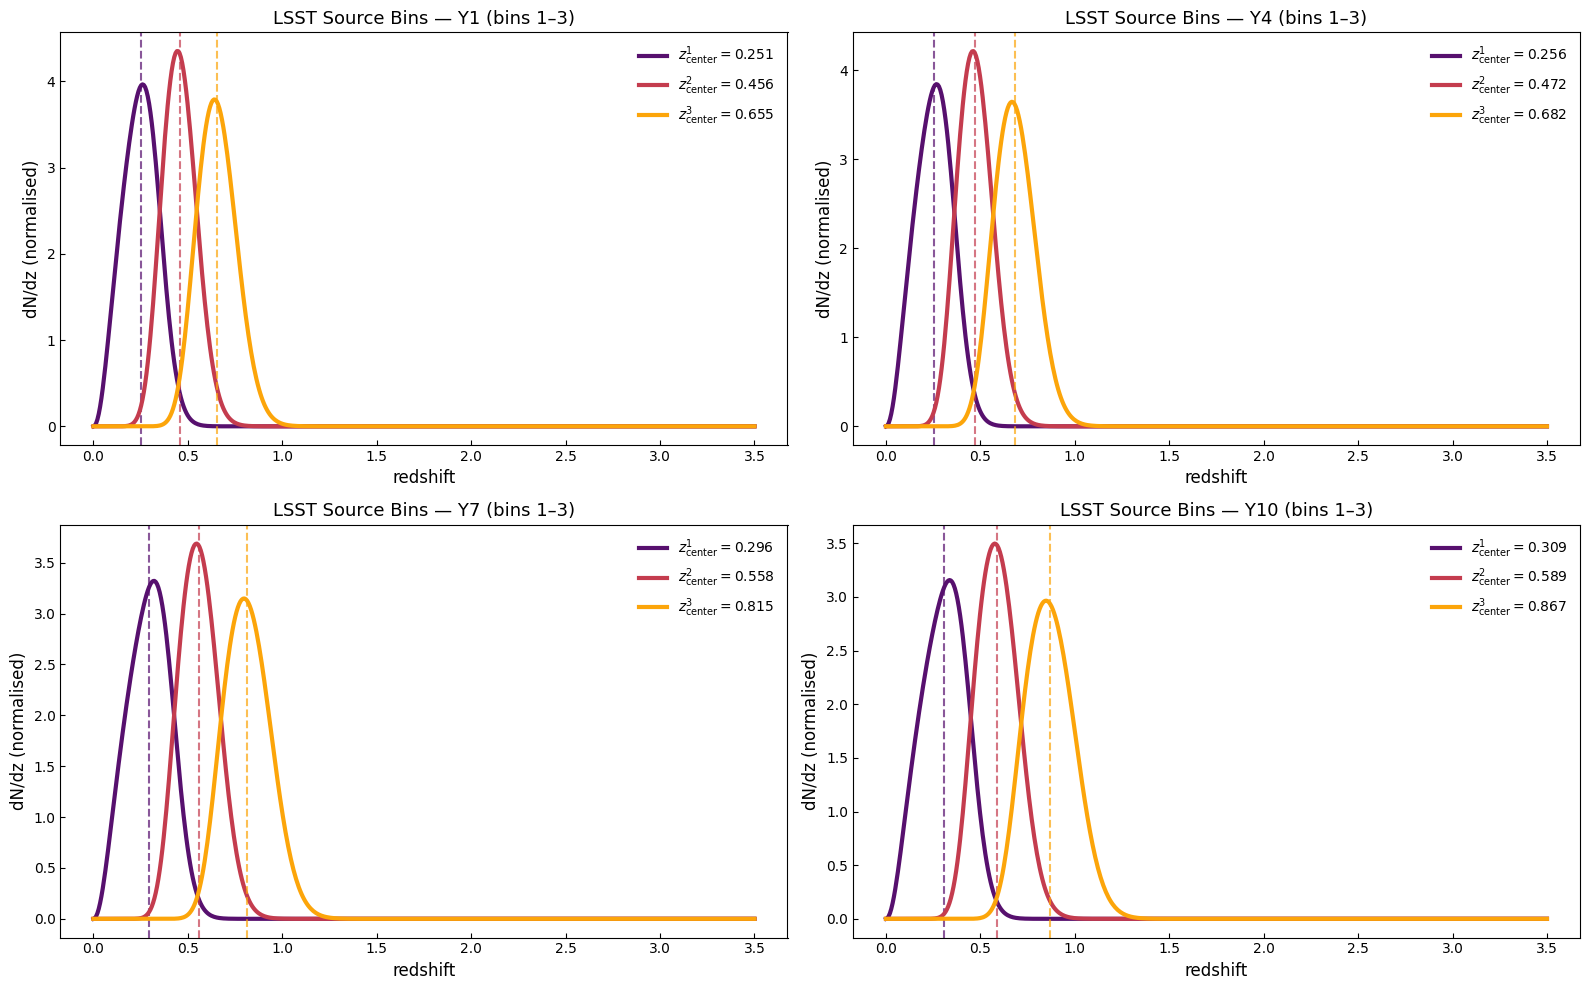

In [10]:
# ── Helper: sample n evenly-spaced colors from a matplotlib colormap ─────
def take_cmap_colors(cmap_name, n, cmap_range=(0.0, 1.0)):
    cmap   = plt.get_cmap(cmap_name)
    values = np.linspace(cmap_range[0], cmap_range[1], n)
    return [mcolors.to_hex(cmap(v)) for v in values]

bin_colors = take_cmap_colors("inferno", Config.LSST_N_BINS, cmap_range=(0.25, 0.8))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, year in enumerate(Config.LSST_FORECAST_YEARS):
    ax = axes[idx]
    for bin_idx in range(Config.LSST_N_BINS):
        bin_data = lsst_samples[year]["source_bins"][bin_idx]
        center   = lsst_samples[year]["source_bin_centers"][bin_idx]
        ax.plot(
            lsst_z_range, bin_data,
            label=rf"$z_\mathrm{{center}}^{{{bin_idx+1}}}={center:.3f}$",
            color=bin_colors[bin_idx], lw=3
        )
        ax.axvline(center, color=bin_colors[bin_idx], ls='--', lw=1.5, alpha=0.7)
    ax.set_xlabel("redshift", fontsize=12)
    ax.set_ylabel("dN/dz (normalised)", fontsize=12)
    ax.set_title(f"LSST Source Bins \u2014 Y{year} (bins 1\u2013{Config.LSST_N_BINS})", fontsize=13)
    ax.legend(frameon=False, fontsize=10)
    ax.tick_params(direction='in')

plt.tight_layout()
plt.show()


## 9 · Plotting

In [11]:
# ============================================================
# Plotting
# ============================================================


def plot_power_spectra_lsst(
    ell, results_gr, fr_results=None, fR_values=None,
    year=None, bin_idx=None, figsize=(14, 10)
):
    """Plot C_l^gg, C_l^kg and f(R)/GR ratios for a given LSST year and bin.

    Parameters
    ----------
    results_gr   : dict with keys 'gg' and 'kg' for GR spectra arrays
    fr_results   : dict {logfR0: {'gg': array, 'kg': array}} or None
    year         : LSST forecast year string (e.g. '1', '4', '7', '10')
    bin_idx      : 0-based tomographic bin index
    """
    Cl_gg_gr  = results_gr['gg']
    Cl_kg_gr  = results_gr['kg']
    bin_label = f"Y{year}, bin {bin_idx+1}"

    fig = plt.figure(figsize=figsize)

    # C_l^{gg}
    plt.subplot(2, 2, 1)
    plt.loglog(ell, Cl_gg_gr, 'b-', linewidth=2.5,
               label=rf'$C_\ell^{{gg}}\;[\mathrm{{GR}},\,{bin_label}]$')
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results:
                plt.loglog(
                    ell, fr_results[logfR0_val]['gg'], '--', linewidth=2,
                    label=rf'$f(R):\,\log_{{10}}|f_{{R0}}|={logfR0_val}$'
                )
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}$', fontsize=12)
    plt.title(rf'Galaxy Auto Spectrum $C_\ell^{{gg}}$ \u2014 {bin_label}', fontsize=13)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)

    # C_l^{kg}
    plt.subplot(2, 2, 2)
    plt.loglog(ell, np.abs(Cl_kg_gr), 'b-', linewidth=2.5,
               label=rf'$C_\ell^{{\kappa g}}\;[\mathrm{{GR}},\,{bin_label}]$')
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results:
                plt.loglog(
                    ell, np.abs(fr_results[logfR0_val]['kg']), '--', linewidth=2,
                    label=rf'$f(R):\,\log_{{10}}|f_{{R0}}|={logfR0_val}$'
                )
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$|C_\ell^{\kappa g}|$', fontsize=12)
    plt.title(rf'CMB Lensing \u00d7 Galaxy $C_\ell^{{\kappa g}}$ \u2014 {bin_label}', fontsize=13)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)

    # Ratio C_l^{gg}(fR)/C_l^{gg}(GR)
    plt.subplot(2, 2, 3)
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results:
                ratio = fr_results[logfR0_val]['gg'] / Cl_gg_gr
                plt.semilogx(ell, ratio, '--', linewidth=2,
                             label=rf'$\log_{{10}}|f_{{R0}}|={logfR0_val}$')
        plt.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}(f(R))/C_\ell^{gg}(\mathrm{GR})$', fontsize=12)
    plt.title(rf'Galaxy Auto Ratio \u2014 {bin_label}', fontsize=13)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    plt.ylim([0.95, 1.45])

    # Ratio C_l^{kg}(fR)/C_l^{kg}(GR)
    plt.subplot(2, 2, 4)
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results:
                ratio = fr_results[logfR0_val]['kg'] / Cl_kg_gr
                plt.semilogx(ell, ratio, '--', linewidth=2,
                             label=rf'$\log_{{10}}|f_{{R0}}|={logfR0_val}$')
        plt.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{\kappa g}(f(R))/C_\ell^{\kappa g}(\mathrm{GR})$', fontsize=12)
    plt.title(rf'Galaxy\u2013CMB Cross Ratio \u2014 {bin_label}', fontsize=13)
    plt.legend(fontsize=9, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    plt.ylim([0.95, 1.45])

    plt.tight_layout()
    return fig


def plot_all_bins_summary(ell, all_results, year, figsize=(16, 5)):
    """Overlay all tomographic bins for a given year (GR only)."""
    bin_colors = take_cmap_colors("inferno", Config.LSST_N_BINS, cmap_range=(0.25, 0.8))
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for bin_idx in range(Config.LSST_N_BINS):
        res = all_results[year][bin_idx]['GR']
        axes[0].loglog(ell, res['gg'], color=bin_colors[bin_idx], lw=2,
                       label=f"bin {bin_idx+1}")
        axes[1].loglog(ell, np.abs(res['kg']), color=bin_colors[bin_idx], lw=2,
                       label=f"bin {bin_idx+1}")

    for ax, ylabel, title in zip(
        axes,
        [r'$C_\ell^{gg}$', r'$|C_\ell^{\kappa g}|$'],
        [rf'Galaxy Auto Spectrum \u2014 Y{year} (GR, all bins)',
         rf'CMB Lensing \u00d7 Galaxy \u2014 Y{year} (GR, all bins)']
    ):
        ax.set_xlabel(r'$\ell$', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(title, fontsize=13)
        ax.legend(fontsize=10)
        ax.grid(True, ls='--', alpha=0.7)

    plt.tight_layout()
    return fig


## 10 · Initialise Emulators & GR Power Spectrum

In [12]:
# ============================================================
# Matter Power Spectra
# ============================================================
# BACCO k grid is in h/Mpc; P(k) is in (Mpc/h)³.
# The single-redshift interpolator built here is used for quick checks only;
# the per-z interpolators in Section 10 are used for the Limber integrals.

bacco_emu, k = initialize_bacco_emulator(
    Config.COSMO_PARAMS,
    k_min=Config.BACCO_K_MIN,
    k_max=Config.BACCO_K_MAX,
    n_k=Config.BACCO_N_K,
    verbose=Config.EMANTIS_VERBOSE
)
# k is in h/Mpc; P returned by BACCO is in (Mpc/h)³
pk_nl_gr = get_bacco_nonlinear_pk(
    bacco_emu,
    Config.COSMO_PARAMS,
    k,
    aexp=Config.COSMO_PARAMS["aexp"]
)
pk_interp_gr = create_power_spectrum_interpolator(k, pk_nl_gr)  # log(k [h/Mpc]) → log(P [(Mpc/h)³])

emantis_emu = initialize_emantis_emulator(verbose=Config.EMANTIS_VERBOSE)


## 11 · Pre-compute Shared Redshift-Dependent Quantities

Quantities that are **independent of the galaxy dN/dz** (comoving distances, Hubble function, growth factor, CMB lensing kernel, and P(k,z) interpolators for GR and f(R)) are computed once here and shared across all LSST tomographic bins and forecast years.


In [13]:
# ============================================================
# Pre-compute Shared Redshift-Dependent Quantities
# ============================================================

# Limber integration grid — capped at Z_BACCO_MAX (z <= 1.5) so that
# BACCO's expfactor = 1/(1+z) stays within its valid range [0.4, 1.0].
# The LSST dN/dz interpolators (built on lsst_z_range up to Z_MAX=3.5)
# return zero outside bin support, so this truncation loses negligible
# signal for LSST source bins 1-3 (bulk lies below z~1.2).
z_grid = np.linspace(Config.Z_MIN, Config.Z_BACCO_MAX, Config.N_Z)

# ── Comoving distances and Hubble function ────────────────────────────────
# chi_vals in pure Mpc; H_vals in km/s/Mpc.
chi_vals = comoving_distance_proper(z_grid, H0, Om_m, Om_lambda)  # Mpc
H_vals   = hubble_function(z_grid, H0, Om_m, Om_lambda)           # km/s/Mpc

# ── Growth factor ─────────────────────────────────────────────────────────
D_vals = growth_factor_D(z_grid, H0, Om_m, Om_lambda)  # dimensionless, D(0)=1
D0     = growth_factor_D(0.0,    H0, Om_m, Om_lambda)

# ── CMB lensing kernel W_kappa(z) ─────────────────────────────────────────
# z_star = 1100 corresponds to the CMB last-scattering surface.
z_star      = 1100.0
Wkappa_vals = cmb_lensing_kernel(z_grid, z_star, H0, Om_m, Om_lambda)  # dimensionless

# ── Multipole array ───────────────────────────────────────────────────────
ell = np.logspace(np.log10(Config.ELL_MIN),
                  np.log10(Config.ELL_MAX),
                  Config.N_ELL)

# ── Safe k bounds in h/Mpc (from the BACCO k grid) ───────────────────────
k_min_safe = k.min() * Config.K_MIN_SAFETY  # h/Mpc
k_max_safe = k.max() * Config.K_MAX_SAFETY  # h/Mpc

# ── P(k,z) interpolators for GR ───────────────────────────────────────────
# One interpolator per z slice; k in h/Mpc, P in (Mpc/h)^3.
# Shared across all bins (dN/dz does not enter the power spectrum).
print("Building GR P(k,z) interpolators...")
pk_interp_gr_z = build_pk_interpolators_over_z(
    bacco_emu, Config.COSMO_PARAMS, k, z_grid
)

# ── P(k,z) interpolators for f(R) gravity ────────────────────────────────
# Pre-built once per logfR0 value; shared across all bins.
print("Building f(R) P(k,z) interpolators...")
pk_interp_fr_z = {}
for logfR0_val in Config.FR_VALUES:
    pk_interp_fr_z[logfR0_val] = build_pk_interpolators_over_z_fr(
        bacco_emu, emantis_emu, Config.COSMO_PARAMS,
        logfR0_val, k, z_grid
    )
    print(f"  f(R) log10|fR0|={logfR0_val} done.")

print("Done.")


Building GR P(k,z) interpolators...
Building f(R) P(k,z) interpolators...
  f(R) log10|fR0|=4 done.
  f(R) log10|fR0|=5 done.
  f(R) log10|fR0|=6 done.
Done.


## 12 · Compute Angular Power Spectra — All LSST Bins, Years & Gravity Models

Iterates over all LSST forecast years (`Y1`, `Y4`, `Y7`, `Y10`) and tomographic bins (1–3). For each `(year, bin)` combination:

1. The LSST dN/dz interpolator is used to compute the galaxy kernel W_g(z).
2. C_ℓ^{gg} and C_ℓ^{κg} are evaluated under GR using the shared `pk_interp_gr_z`.
3. The same spectra are re-evaluated for each f(R) value using `pk_interp_fr_z[logfR0]`.

Results are stored in `all_results[year][bin_idx][gravity_key]` where `gravity_key` is `'GR'` or an integer `logfR0_val`.


In [ ]:
# ============================================================
# Angular Power Spectra — All LSST Years x Bins x Gravity Models
# ============================================================
# Results stored in nested dict:
#   all_results[year][bin_idx]['GR']       = {'gg': array, 'kg': array}
#   all_results[year][bin_idx][logfR0_val] = {'gg': array, 'kg': array}

all_results     = {year: {} for year in Config.LSST_FORECAST_YEARS}
bias_func_local = lambda z: bias_function(z, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)

for year in Config.LSST_FORECAST_YEARS:
    for bin_idx in range(Config.LSST_N_BINS):
        print(f"\n--- Y{year}, bin {bin_idx+1} ---")

        # ── Galaxy kernel W_g(z) for this (year, bin) ─────────────────────
        # galaxy_lensing_kernel evaluates dNdz_func_bin at each z in z_grid
        # via the LSST interpolator.  All distances are in pure Mpc.
        dNdz_func_bin = dNdz_funcs[year][bin_idx]

        Wg_vals = np.array([
            galaxy_lensing_kernel(
                z, z_grid, dNdz_func_bin, bias_func_local,
                H0, Om_m, Om_lambda
            )
            for z in z_grid
        ])

        all_results[year][bin_idx] = {}

        # ── GR ────────────────────────────────────────────────────────────
        Cl_gg_gr = compute_Cl_galaxy_auto(
            ell, pk_interp_gr_z, z_grid, Wg_vals,
            chi_vals, H_vals, D_vals, D0, Config.c,
            H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
            k_min=k_min_safe, k_max=k_max_safe
        )
        Cl_kg_gr = compute_Cl_galaxy_cmb_cross(
            ell, pk_interp_gr_z, z_grid, Wg_vals,
            chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
            H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
            k_min=k_min_safe, k_max=k_max_safe
        )
        all_results[year][bin_idx]['GR'] = {'gg': Cl_gg_gr, 'kg': Cl_kg_gr}
        print("  GR done.")

        # ── f(R) gravity ──────────────────────────────────────────────────
        for logfR0_val in Config.FR_VALUES:
            Cl_gg_fr = compute_Cl_galaxy_auto(
                ell, pk_interp_fr_z[logfR0_val], z_grid, Wg_vals,
                chi_vals, H_vals, D_vals, D0, Config.c,
                H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
                k_min=k_min_safe, k_max=k_max_safe
            )
            Cl_kg_fr = compute_Cl_galaxy_cmb_cross(
                ell, pk_interp_fr_z[logfR0_val], z_grid, Wg_vals,
                chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
                H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
                k_min=k_min_safe, k_max=k_max_safe
            )
            all_results[year][bin_idx][logfR0_val] = {'gg': Cl_gg_fr, 'kg': Cl_kg_fr}
            print(f"  f(R) log10|fR0|={logfR0_val} done.")

print("\nAll spectra computed.")



--- Y1, bin 1 ---
  GR done.
  f(R) log10|fR0|=4 done.
  f(R) log10|fR0|=5 done.
  f(R) log10|fR0|=6 done.

--- Y1, bin 2 ---
  GR done.
  f(R) log10|fR0|=4 done.
  f(R) log10|fR0|=5 done.
  f(R) log10|fR0|=6 done.

--- Y1, bin 3 ---
  GR done.
  f(R) log10|fR0|=4 done.
  f(R) log10|fR0|=5 done.
  f(R) log10|fR0|=6 done.

--- Y4, bin 1 ---
  GR done.
  f(R) log10|fR0|=4 done.
  f(R) log10|fR0|=5 done.
  f(R) log10|fR0|=6 done.

--- Y4, bin 2 ---
  GR done.
  f(R) log10|fR0|=4 done.
  f(R) log10|fR0|=5 done.
  f(R) log10|fR0|=6 done.

--- Y4, bin 3 ---
  GR done.
  f(R) log10|fR0|=4 done.
  f(R) log10|fR0|=5 done.
  f(R) log10|fR0|=6 done.

--- Y7, bin 1 ---
  GR done.
  f(R) log10|fR0|=4 done.
  f(R) log10|fR0|=5 done.
  f(R) log10|fR0|=6 done.

--- Y7, bin 2 ---
  GR done.
  f(R) log10|fR0|=4 done.
  f(R) log10|fR0|=5 done.
  f(R) log10|fR0|=6 done.

--- Y7, bin 3 ---
  GR done.
  f(R) log10|fR0|=4 done.
  f(R) log10|fR0|=5 done.
  f(R) log10|fR0|=6 done.

--- Y10, bin 1 ---


## 13 · Results

Generates one 4-panel figure per `(forecast year, tomographic bin)` combination showing C_ℓ^{gg}, C_ℓ^{κg}, and both f(R)/GR ratios.

A summary plot per year then overlays all three bins on the same axes (GR only) for a quick comparison of the tomographic signal.


In [ ]:
# ============================================================
# Plot Results — per (year, bin) + per-year summary
# ============================================================

for year in Config.LSST_FORECAST_YEARS:
    for bin_idx in range(Config.LSST_N_BINS):
        fr_results_bin = {
            logfR0_val: all_results[year][bin_idx][logfR0_val]
            for logfR0_val in Config.FR_VALUES
        }
        fig = plot_power_spectra_lsst(
            ell,
            results_gr   = all_results[year][bin_idx]['GR'],
            fr_results   = fr_results_bin,
            fR_values    = Config.FR_VALUES,
            year         = year,
            bin_idx      = bin_idx,
            figsize      = Config.FIGURE_SIZE
        )
        plt.show()

    # ── Summary: all bins overlaid (GR only) ──────────────────────────
    fig_summary = plot_all_bins_summary(ell, all_results, year)
    plt.show()
